# Decision Tree — Baseline
Treino em 2020–2023, teste em 2024. Sem SMOTE — desbalanceamento tratado via `class_weight='balanced'`.
Decision Tree não lida com NaN nativamente — imputa-se antes do classificador.
Métricas prioritárias: **Sensibilidade > AUPRC > ROC-AUC > Especificidade > F1**

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.metrics import (
    precision_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

BASE_DIR     = '../../data/features/baseline'
OUTPUT_MOD   = '../../output/modelos'
OUTPUT_MET   = '../../output/metricas'
ALGO         = 'decision_tree'
DATASET      = 'baseline'
RANDOM_STATE = 42
YEAR_COL     = 'year'

## 1. Carregamento dos dados

In [2]:
X_train = pd.read_parquet(os.path.join(BASE_DIR, 'X_train.parquet'))
y_train = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
X_test  = pd.read_parquet(os.path.join(BASE_DIR, 'X_test.parquet'))
y_test  = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()

mask    = y_train.notna()
X_train = X_train[mask]
y_train = y_train[mask]

print(f'X_train: {X_train.shape} | Óbitos: {int(y_train.sum()):,} ({y_train.mean()*100:.2f}%)')
print(f'X_test:  {X_test.shape}  | Óbitos: {int(y_test.sum()):,} ({y_test.mean()*100:.2f}%)')

X_train: (149544, 52) | Óbitos: 2,625 (1.76%)
X_test:  (160534, 52)  | Óbitos: 5,295 (3.30%)


## 2. Pipeline
Decision Tree não aceita NaN — imputa-se mediana para contínuas e moda para binárias.

In [3]:
ALRM_COLS = [c for c in X_train.columns if c.startswith('ALRM_')]
GRAV_COLS = [c for c in X_train.columns if c.startswith('GRAV_')]
SYMP_COLS = [
    'FEBRE','MIALGIA','CEFALEIA','EXANTEMA','VOMITO','NAUSEA',
    'DOR_COSTAS','CONJUNTVIT','ARTRITE','ARTRALGIA','PETEQUIA_N',
    'LEUCOPENIA','LACO','DOR_RETRO','DIABETES','HEMATOLOG',
    'HEPATOPAT','RENAL','HIPERTENSA','AUTO_IMUNE',
]
SYMP_COLS = [c for c in SYMP_COLS if c in X_train.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ('alrm_grav',
         SimpleImputer(strategy='constant', fill_value=0),
         ALRM_COLS + GRAV_COLS),

        ('sintomas',
         SimpleImputer(strategy='most_frequent'),
         SYMP_COLS),

        ('continuas',
         SimpleImputer(strategy='median'),
         ['age_years', 'epi_week']),

        ('sexo',
         Pipeline([
             ('enc', OrdinalEncoder(categories=[['F', 'M']],
                                    handle_unknown='use_encoded_value',
                                    unknown_value=np.nan)),
             ('imp', SimpleImputer(strategy='most_frequent')),
         ]),
         ['CS_SEXO']),

        ('escol',
         SimpleImputer(strategy='median'),
         ['CS_ESCOL_N']),

        ('raca',
         Pipeline([
             ('imp', SimpleImputer(strategy='most_frequent')),
             ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
         ]),
         ['CS_RACA']),

        ('gestant',
         Pipeline([
             ('imp', SimpleImputer(strategy='most_frequent')),
             ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
         ]),
         ['CS_GESTANT']),

        ('uf',
         OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         ['SG_UF']),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

print('Pipeline definido.')

Pipeline definido.


## 3. Treinamento

In [4]:
def prep_X(df):
    df = df.copy()
    if 'age_years' in df.columns:
        df.loc[df['age_years'] > 120, 'age_years'] = np.nan
    return df.drop(columns=[YEAR_COL], errors='ignore')

X_train_prep = prep_X(X_train)
X_test_prep  = prep_X(X_test)

pipeline.fit(X_train_prep, y_train)
print('Treinamento concluído.')
print(f'Profundidade real da árvore: {pipeline["clf"].get_depth()}')
print(f'Número de folhas: {pipeline["clf"].get_n_leaves()}')

Treinamento concluído.
Profundidade real da árvore: 10
Número de folhas: 220


## 4. Avaliação

=== Decision Tree — Baseline (2020–2023 → 2024) ===
  sensibilidade: 0.7394
  especificidade: 0.9015
  auprc: 0.5523
  roc_auc: 0.8761
  f1: 0.3195
  precisao: 0.2038
  threshold: 0.5
  n_train: 149544
  n_obito_train: 2625

              precision    recall  f1-score   support

        Cura       0.99      0.90      0.94    155239
       Óbito       0.20      0.74      0.32      5295

    accuracy                           0.90    160534
   macro avg       0.60      0.82      0.63    160534
weighted avg       0.96      0.90      0.92    160534



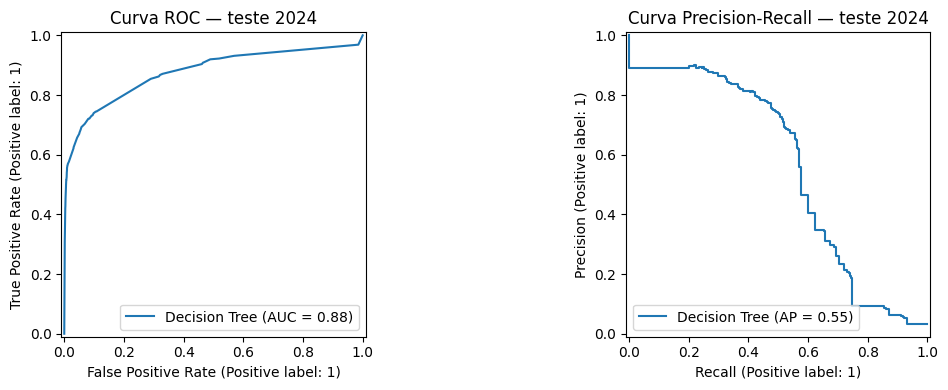

In [5]:
y_te  = y_test.dropna()
proba = pipeline.predict_proba(X_test_prep)[:, 1]
proba = proba[y_test.notna().values]

def calcular_metricas(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'auprc':          round(average_precision_score(y_true, y_pred_proba), 4),
        'roc_auc':        round(roc_auc_score(y_true, y_pred_proba), 4),
        'f1':             round(f1_score(y_true, y_pred), 4),
        'precisao':       round(precision_score(y_true, y_pred, zero_division=0), 4),
        'threshold':      threshold,
        'n_train':        len(X_train_prep),
        'n_obito_train':  int(y_train.sum()),
    }

metricas = calcular_metricas(y_te, proba)
print('=== Decision Tree — Baseline (2020–2023 → 2024) ===')
for k, v in metricas.items():
    print(f'  {k}: {v}')

print()
print(classification_report(y_te, (proba >= 0.5).astype(int), target_names=['Cura', 'Óbito']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, proba, ax=axes[0], name='Decision Tree')
axes[0].set_title('Curva ROC — teste 2024')
PrecisionRecallDisplay.from_predictions(y_te, proba, ax=axes[1], name='Decision Tree')
axes[1].set_title('Curva Precision-Recall — teste 2024')
plt.tight_layout()
plt.show()

## 5. Matriz de Confusão (threshold = 0.5)

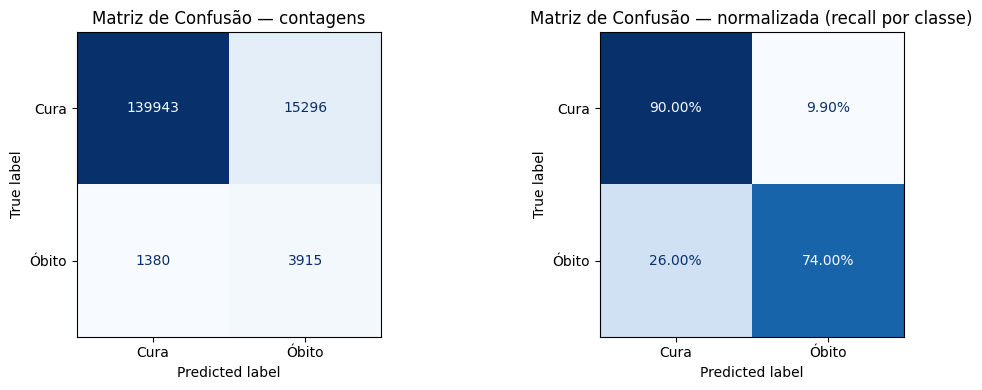

VP (óbitos detectados):   3,915
FN (óbitos perdidos):     1,380
FP (falsos alarmes):      15,296
VN (curas classificadas): 139,943


In [6]:
y_pred_05      = (proba >= 0.5).astype(int)
cm             = confusion_matrix(y_te, y_pred_05)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(cm, display_labels=['Cura', 'Óbito']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — contagens')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=['Cura', 'Óbito']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão — normalizada (recall por classe)')
for text in axes[1].texts:
    text.set_text(f'{float(text.get_text()):.2%}')

plt.tight_layout()
plt.show()

print(f'VP (óbitos detectados):   {tp:,}')
print(f'FN (óbitos perdidos):     {fn:,}')
print(f'FP (falsos alarmes):      {fp:,}')
print(f'VN (curas classificadas): {tn:,}')

## 6. Análise de threshold

Threshold padrão  (0.50): sens=0.7394 | esp=0.9015
Threshold Youden  (0.60): sens=0.7390 | esp=0.9020
Threshold sens≥90% (0.20): sens=0.9037 | esp=0.5389


,threshold,sensibilidade,especificidade,precisao,f1,tp,fp,fn,tn
0,0.05,0.9686,0.0146,0.0324,0.0628,5129,152974,166,2265
1,0.10,0.9195,0.5108,0.0603,0.1131,4869,75939,426,79300
2,0.15,0.9084,0.5351,0.0625,0.1169,4810,72168,485,83071
3,0.20,0.9037,0.5389,0.0627,0.1172,4785,71584,510,83655
4,0.25,0.8697,0.6730,0.0832,0.1518,4605,50766,690,104473
5,0.30,0.8697,0.6730,0.0832,0.1518,4605,50766,690,104473
6,0.35,0.8542,0.7100,0.0913,0.1649,4523,45025,772,110214
7,0.40,0.8542,0.7100,0.0913,0.1649,4523,45025,772,110214
8,0.45,0.7443,0.8948,0.1945,0.3084,3941,16325,1354,138914
9,0.50,0.7394,0.9015,0.2038,0.3195,3915,15296,1380,139943


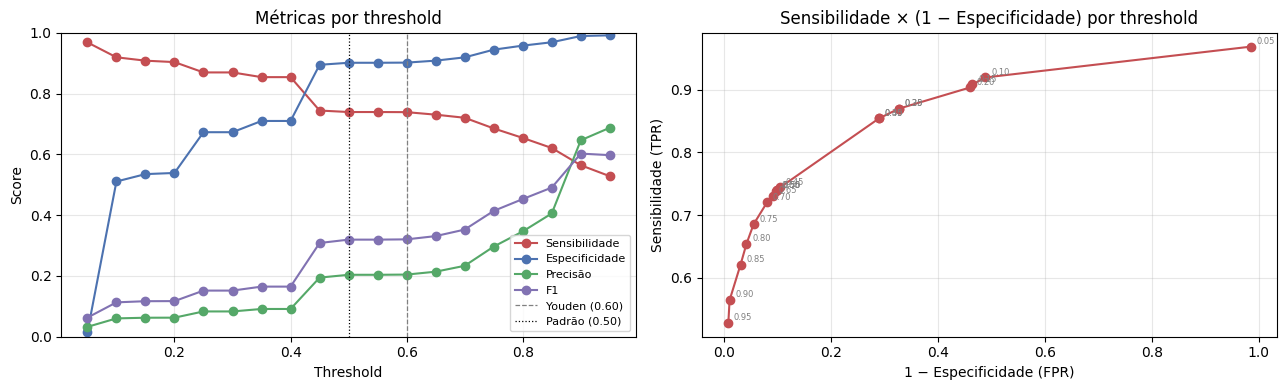

In [7]:
thresholds = np.arange(0.05, 0.96, 0.05)
rows = []

for t in thresholds:
    y_pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    rows.append({
        'threshold':      round(t, 2),
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'precisao':       round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0,
        'f1':             round(f1_score(y_te, y_pred), 4),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
    })

df_thresh = pd.DataFrame(rows)
df_thresh['youden'] = df_thresh['sensibilidade'] + df_thresh['especificidade'] - 1
idx_youden = df_thresh['youden'].idxmax()

high_sens = df_thresh[df_thresh['sensibilidade'] >= 0.90]
idx_90    = high_sens['especificidade'].idxmax() if not high_sens.empty else None

print(f"Threshold padrão  (0.50): sens={df_thresh.loc[df_thresh['threshold']==0.50, 'sensibilidade'].values[0]:.4f} "
      f"| esp={df_thresh.loc[df_thresh['threshold']==0.50, 'especificidade'].values[0]:.4f}")
print(f"Threshold Youden  ({df_thresh.loc[idx_youden,'threshold']:.2f}): "
      f"sens={df_thresh.loc[idx_youden,'sensibilidade']:.4f} | esp={df_thresh.loc[idx_youden,'especificidade']:.4f}")
if idx_90 is not None:
    print(f"Threshold sens≥90% ({df_thresh.loc[idx_90,'threshold']:.2f}): "
          f"sens={df_thresh.loc[idx_90,'sensibilidade']:.4f} | esp={df_thresh.loc[idx_90,'especificidade']:.4f}")

display(df_thresh.drop(columns='youden'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_thresh['threshold'], df_thresh['sensibilidade'], 'o-', color='#C44E52', label='Sensibilidade')
axes[0].plot(df_thresh['threshold'], df_thresh['especificidade'], 'o-', color='#4C72B0', label='Especificidade')
axes[0].plot(df_thresh['threshold'], df_thresh['precisao'],       'o-', color='#55A868', label='Precisão')
axes[0].plot(df_thresh['threshold'], df_thresh['f1'],             'o-', color='#8172B2', label='F1')
axes[0].axvline(df_thresh.loc[idx_youden, 'threshold'], color='gray', linestyle='--',
                linewidth=0.9, label=f'Youden ({df_thresh.loc[idx_youden,"threshold"]:.2f})')
axes[0].axvline(0.5, color='black', linestyle=':', linewidth=0.9, label='Padrão (0.50)')
axes[0].set_title('Métricas por threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(1 - df_thresh['especificidade'], df_thresh['sensibilidade'], 'o-', color='#C44E52')
for _, row in df_thresh.iterrows():
    axes[1].annotate(f"{row['threshold']:.2f}",
                     (1 - row['especificidade'], row['sensibilidade']),
                     textcoords='offset points', xytext=(4, 2), fontsize=6, color='gray')
axes[1].set_title('Sensibilidade × (1 − Especificidade) por threshold')
axes[1].set_xlabel('1 − Especificidade (FPR)')
axes[1].set_ylabel('Sensibilidade (TPR)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Importância das features

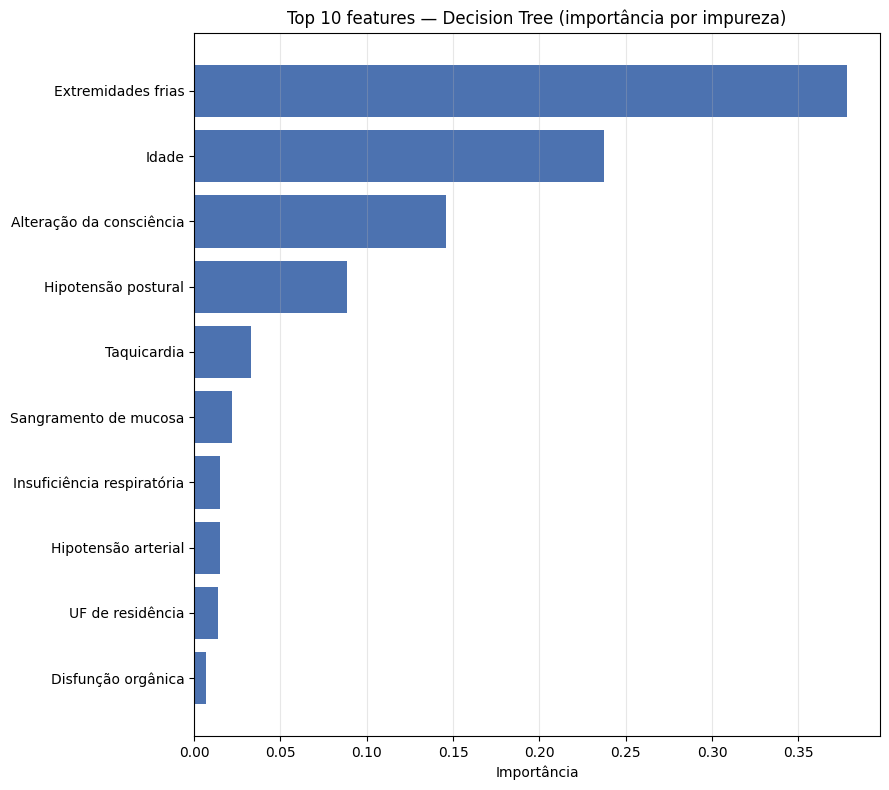

,label,feature,importance
14,Extremidades frias,GRAV_EXTRE,0.378297
44,Idade,age_years,0.237476
22,Alteração da consciência,GRAV_CONSC,0.146154
0,Hipotensão postural,ALRM_HIPOT,0.088735
13,Taquicardia,GRAV_TAQUI,0.033135
3,Sangramento de mucosa,ALRM_SANG,0.022237
12,Insuficiência respiratória,GRAV_INSUF,0.014950
15,Hipotensão arterial,GRAV_HIPOT,0.014889
59,UF de residência,SG_UF,0.013621
23,Disfunção orgânica,GRAV_ORGAO,0.007049


In [8]:
FEATURE_LABELS = {
    # Variáveis contínuas / temporais
    'age_years':          'Idade',
    'epi_week':           'Semana epidemiológica',
    # Dados do paciente
    'CS_SEXO':            'Sexo',
    'CS_GESTANT':         'Gestante',
    'CS_RACA':            'Raça/Cor',
    'CS_ESCOL_N':         'Escolaridade',
    'SG_UF':              'UF de residência',
    # CS_RACA one-hot
    'CS_RACA_1.0':        'Raça: Branca',
    'CS_RACA_2.0':        'Raça: Preta',
    'CS_RACA_3.0':        'Raça: Amarela',
    'CS_RACA_4.0':        'Raça: Parda',
    'CS_RACA_5.0':        'Raça: Indígena',
    # CS_GESTANT one-hot
    'CS_GESTANT_1.0':     'Gestante: 1º trimestre',
    'CS_GESTANT_2.0':     'Gestante: 2º trimestre',
    'CS_GESTANT_3.0':     'Gestante: 3º trimestre',
    'CS_GESTANT_4.0':     'Gestante: idade gestacional ignorada',
    'CS_GESTANT_5.0':     'Gestante: não',
    'CS_GESTANT_6.0':     'Gestante: não se aplica',
    # Sintomas clássicos
    'FEBRE':              'Febre',
    'MIALGIA':            'Mialgia',
    'CEFALEIA':           'Cefaleia',
    'EXANTEMA':           'Exantema',
    'VOMITO':             'Vômito',
    'NAUSEA':             'Náusea',
    'DOR_COSTAS':         'Dor nas costas',
    'CONJUNTVIT':         'Conjuntivite',
    'ARTRITE':            'Artrite',
    'ARTRALGIA':          'Artralgia',
    'PETEQUIA_N':         'Petéquia',
    'LEUCOPENIA':         'Leucopenia',
    'LACO':               'Prova do laço',
    'DOR_RETRO':          'Dor retro-orbital',
    # Comorbidades
    'DIABETES':           'Diabetes',
    'HEMATOLOG':          'Doença hematológica',
    'HEPATOPAT':          'Hepatopatia',
    'RENAL':              'Doença renal',
    'HIPERTENSA':         'Hipertensão arterial',
    'AUTO_IMUNE':         'Doença autoimune',
    # Sinais de alarme
    'ALRM_ABDOM':         'Dor abdominal intensa',
    'ALRM_VOM':           'Vômitos persistentes',
    'ALRM_LIQ':           'Acúmulo de líquidos',
    'ALRM_HEMAT':         'Aumento do hematócrito',
    'ALRM_PLAQ':          'Queda abrupta de plaquetas',
    'ALRM_SANG':          'Sangramento de mucosa',
    'ALRM_LETAR':         'Letargia/irritabilidade',
    'ALRM_HEPAT':         'Hepatomegalia',
    'ALRM_HIPOT':         'Hipotensão postural',
    # Dengue grave
    'GRAV_HIPOT':         'Hipotensão arterial',
    'GRAV_PULSO':         'Pulso fraco e filiforme',
    'GRAV_EXTRE':         'Extremidades frias',
    'GRAV_ENCH':          'Enchimento capilar lento',
    'GRAV_TAQUI':         'Taquicardia',
    'GRAV_CONV':          'Convulsão',
    'GRAV_INSUF':         'Insuficiência respiratória',
    'GRAV_HEMAT':         'Hematêmese',
    'GRAV_MELEN':         'Melena',
    'GRAV_METRO':         'Metrorragia',
    'GRAV_SANG':          'Sangramento intenso',
    'GRAV_AST':           'Astenia grave',
    'GRAV_MIOC':          'Miocardite',
    'GRAV_CONSC':         'Alteração da consciência',
    'GRAV_ORGAO':         'Disfunção orgânica',
}

feature_names = pipeline['pre'].get_feature_names_out()
importances   = pipeline['clf'].feature_importances_

df_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
df_imp['label'] = df_imp['feature'].map(lambda f: FEATURE_LABELS.get(f, f))
df_imp = df_imp.sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top_n  = 10
df_top = df_imp.head(top_n)
ax.barh(df_top['label'][::-1], df_top['importance'][::-1], color='#4C72B0')
ax.set_title(f'Top {top_n} features — Decision Tree (importância por impureza)')
ax.set_xlabel('Importância')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

display(df_imp.head(15)[['label', 'feature', 'importance']])

## 8. Visualização da árvore (ramos superiores)
Exibe apenas os primeiros níveis para interpretação clínica.

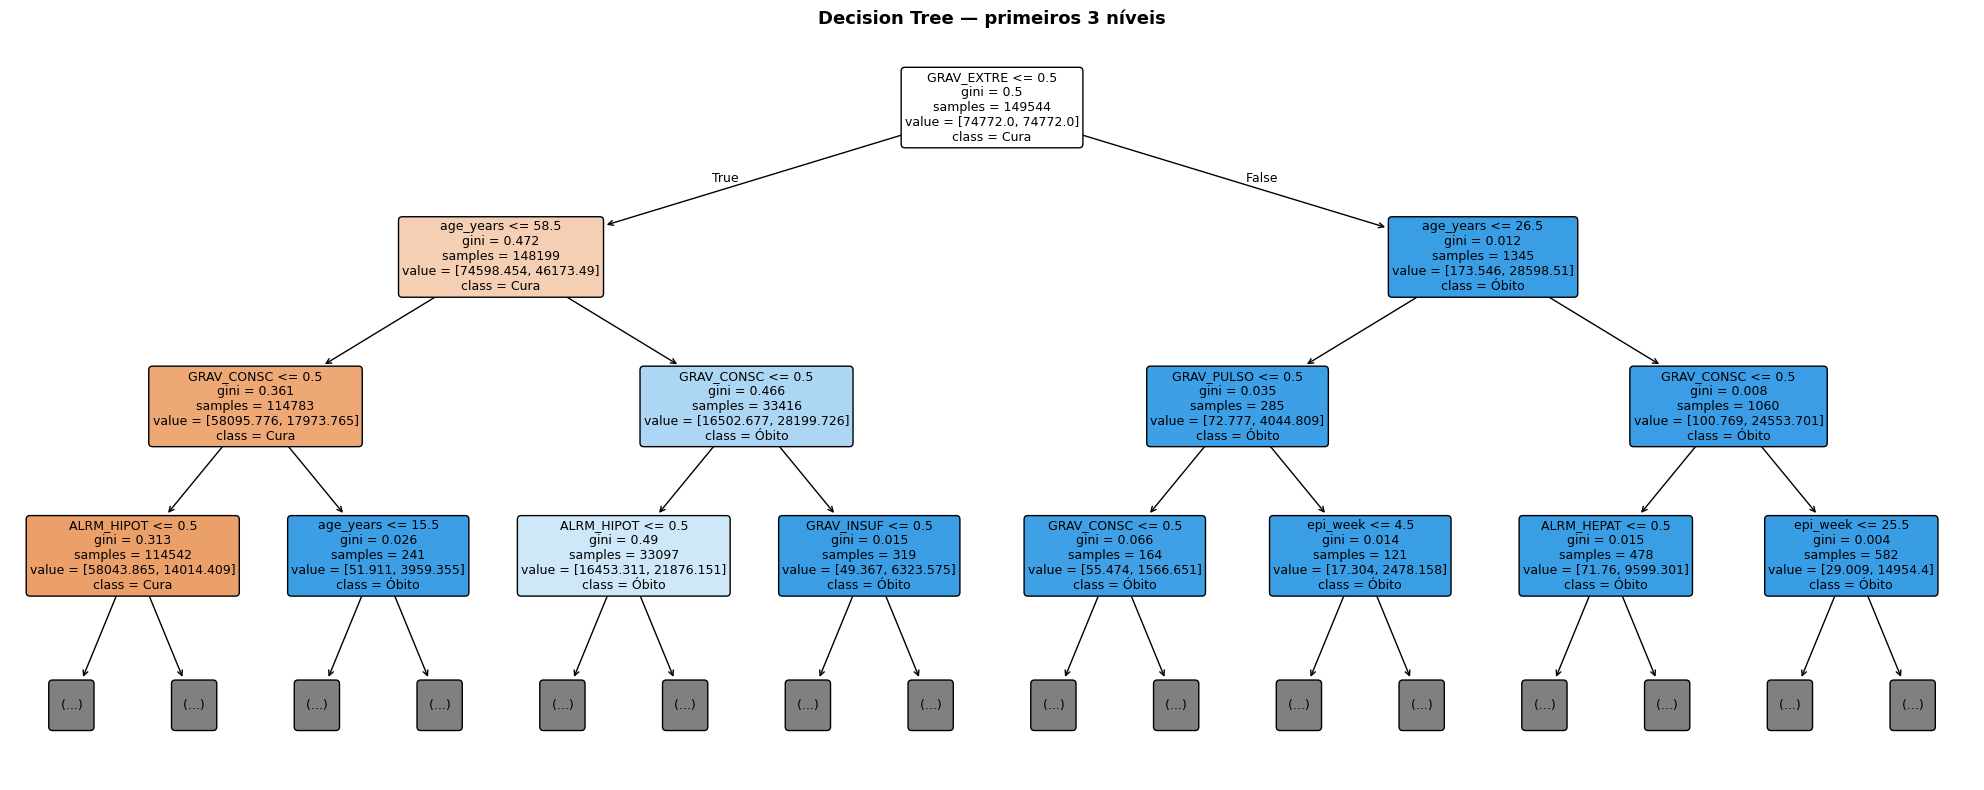

In [9]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipeline['clf'],
    feature_names=pipeline['pre'].get_feature_names_out(),
    class_names=['Cura', 'Óbito'],
    filled=True,
    rounded=True,
    max_depth=3,
    ax=ax,
    fontsize=9,
)
ax.set_title('Decision Tree — primeiros 3 níveis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('../../output/plots', 'decision_tree_structure.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Salvamento

In [10]:
os.makedirs(OUTPUT_MOD, exist_ok=True)
os.makedirs(OUTPUT_MET, exist_ok=True)

model_path = os.path.join(OUTPUT_MOD, f'{ALGO}_{DATASET}.joblib')
joblib.dump(pipeline, model_path)
print(f'Modelo salvo: {model_path}')

df_met = pd.DataFrame([metricas])
df_met['label']   = f'{ALGO}_{DATASET}'
df_met['dataset'] = DATASET
met_path = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET}.parquet')
df_met.to_parquet(met_path, index=False)
print(f'Métricas salvas: {met_path}')

df_pred = pd.DataFrame({'y_true': y_te.values, 'y_proba': proba})
pred_path = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET}_predicoes.parquet')
df_pred.to_parquet(pred_path, index=False)
print(f'Predições salvas: {pred_path}')

Modelo salvo: ../../output/modelos/decision_tree_baseline.joblib
Métricas salvas: ../../output/metricas/decision_tree_baseline.parquet
Predições salvas: ../../output/metricas/decision_tree_baseline_predicoes.parquet


## 10. Otimização de Hiperparâmetros (GridSearchCV)
Busca sobre `max_depth`, `min_samples_leaf`, `min_samples_split` e `criterion`.
Avaliação por `StratifiedKFold(5)` dentro do train set (2020–2023). Scoring: `average_precision` (AUPRC).

In [11]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

def build_pipeline():
    return Pipeline([
        ('pre', preprocessor),
        ('clf', DecisionTreeClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE,
        )),
    ])

param_grid = {
    'clf__max_depth':        [5, 10, 20, None],
    'clf__min_samples_leaf': [5, 10, 20],
    'clf__criterion':        ['gini', 'entropy'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=build_pipeline(),
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid_search.fit(X_train_prep, y_train)

print(f'\nMelhores parâmetros: {grid_search.best_params_}')
print(f'Melhor AUPRC (CV):   {grid_search.best_score_:.4f}')

df_cv = pd.DataFrame(grid_search.cv_results_)
df_cv = df_cv[['param_clf__max_depth', 'param_clf__min_samples_leaf', 'param_clf__criterion',
               'mean_test_score', 'std_test_score', 'rank_test_score']]
df_cv = df_cv.sort_values('rank_test_score')
display(df_cv)

Fitting 5 folds for each of 24 candidates, totalling 120 fits



Melhores parâmetros: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 20}
Melhor AUPRC (CV):   0.5615


,param_clf__max_depth,param_clf__min_samples_leaf,param_clf__criterion,mean_test_score,std_test_score,rank_test_score
17,10,20,entropy,0.561473,0.017073,1
5,10,20,gini,0.551190,0.021578,2
20,20,20,entropy,0.544743,0.017401,3
16,10,10,entropy,0.543757,0.017952,4
23,None,20,entropy,0.537706,0.017937,5
8,20,20,gini,0.532411,0.018186,6
4,10,10,gini,0.527345,0.018877,7
11,None,20,gini,0.526802,0.018699,8
15,10,5,entropy,0.522422,0.013449,9
2,5,20,gini,0.521537,0.017785,10


## 11. Avaliação — Modelo Tunado

=== Comparação: Baseline vs Tunado ===
Métrica              Baseline     Tunado
----------------------------------------
sensibilidade          0.7394     0.7347  (-0.0047)
especificidade         0.9015     0.8964  (-0.0051)
auprc                  0.5523     0.5685  (+0.0162)
roc_auc                0.8761     0.8845  (+0.0084)
f1                     0.3195     0.3080  (-0.0115)


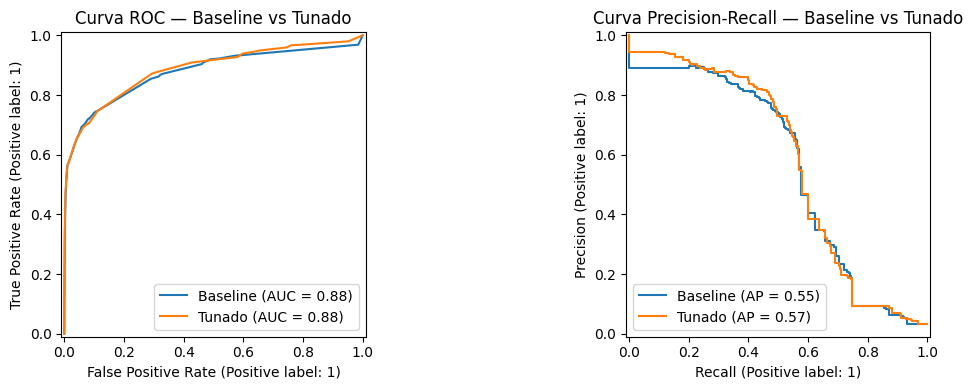

In [12]:
pipeline_tuned = grid_search.best_estimator_

proba_tuned = pipeline_tuned.predict_proba(X_test_prep)[:, 1]
proba_tuned = proba_tuned[y_test.notna().values]

metricas_tuned = calcular_metricas(y_te, proba_tuned)

print('=== Comparação: Baseline vs Tunado ===')
print(f"{'Métrica':<18} {'Baseline':>10} {'Tunado':>10}")
print('-' * 40)
for k in ['sensibilidade', 'especificidade', 'auprc', 'roc_auc', 'f1']:
    v_base  = metricas[k]
    v_tuned = metricas_tuned[k]
    diff    = v_tuned - v_base
    sinal   = '+' if diff >= 0 else ''
    print(f'{k:<18} {v_base:>10.4f} {v_tuned:>10.4f}  ({sinal}{diff:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, proba,       ax=axes[0], name='Baseline')
RocCurveDisplay.from_predictions(y_te, proba_tuned, ax=axes[0], name='Tunado')
axes[0].set_title('Curva ROC — Baseline vs Tunado')

PrecisionRecallDisplay.from_predictions(y_te, proba,       ax=axes[1], name='Baseline')
PrecisionRecallDisplay.from_predictions(y_te, proba_tuned, ax=axes[1], name='Tunado')
axes[1].set_title('Curva Precision-Recall — Baseline vs Tunado')
plt.tight_layout()
plt.show()

## 12. Salvamento — Modelo Tunado

In [13]:
DATASET_TUNED = f'{DATASET}_tuned'

model_path_tuned = os.path.join(OUTPUT_MOD, f'{ALGO}_{DATASET_TUNED}.joblib')
joblib.dump(pipeline_tuned, model_path_tuned)
print(f'Modelo salvo: {model_path_tuned}')

df_met_tuned = pd.DataFrame([metricas_tuned])
df_met_tuned['label']       = f'{ALGO}_{DATASET_TUNED}'
df_met_tuned['dataset']     = DATASET_TUNED
df_met_tuned['best_params'] = str(grid_search.best_params_)
met_path_tuned = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET_TUNED}.parquet')
df_met_tuned.to_parquet(met_path_tuned, index=False)
print(f'Métricas salvas: {met_path_tuned}')

df_pred_tuned = pd.DataFrame({'y_true': y_te.values, 'y_proba': proba_tuned})
pred_path_tuned = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET_TUNED}_predicoes.parquet')
df_pred_tuned.to_parquet(pred_path_tuned, index=False)
print(f'Predições salvas: {pred_path_tuned}')

Modelo salvo: ../../output/modelos/decision_tree_baseline_tuned.joblib


Métricas salvas: ../../output/metricas/decision_tree_baseline_tuned.parquet
Predições salvas: ../../output/metricas/decision_tree_baseline_tuned_predicoes.parquet
